#### **<h1 align="center"><span style="color:#06445e;">Exploratory Data Analysis (EDA)</span>**

#### **<h2 align="center"><span style="color:#06445e;">Task</span>**
### **Description: Perform an exploratory analysis on a given dataset to identify patterns, trends, and summary statistics.**

#### **<h2 align="center"><span style="color:#06445e;">Objectives:</span>**

### Calculate summary statistics (mean, median, mode, standard deviation).
### Visualize data distributions using histograms, boxplots, and scatter plots.
### Find correlations between numerical features

## Import Libraries

In [85]:
import pandas as  pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

## Load data

In [25]:
stock_price_df = pd.read_csv("dataset/stock_prices.csv")

## Start Exploratory Data Analysis

### Data  Inspection

#### Top 5 rows of the data

In [34]:
stock_price_df.head()

,symbol,date,open,high,low,close,volume
0,AAL,2014-01-02,25.0700,25.8200,25.0600,25.3600,8998943
1,AAPL,2014-01-02,79.3828,79.5756,78.8601,79.0185,58791957
2,AAP,2014-01-02,110.3600,111.8800,109.2900,109.7400,542711
3,ABBV,2014-01-02,52.1200,52.3300,51.5200,51.9800,4569061
4,ABC,2014-01-02,70.1100,70.2300,69.4800,69.8900,1148391


#### Last 5 rows of the data

In [35]:
stock_price_df.tail()

,symbol,date,open,high,low,close,volume
497467,XYL,2017-12-29,68.53,68.80,67.92,68.20,1046677
497468,YUM,2017-12-29,82.64,82.71,81.59,81.61,1347613
497469,ZBH,2017-12-29,121.75,121.95,120.62,120.67,1023624
497470,ZION,2017-12-29,51.28,51.55,50.81,50.83,1261916
497471,ZTS,2017-12-29,72.55,72.76,72.04,72.04,1704122


#### Basic information about the data

In [36]:
stock_price_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 497472 entries, 0 to 497471
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   symbol  497472 non-null  object 
 1   date    497472 non-null  object 
 2   open    497461 non-null  float64
 3   high    497464 non-null  float64
 4   low     497464 non-null  float64
 5   close   497472 non-null  float64
 6   volume  497472 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 26.6+ MB


#### Basic information about the data

In [37]:
stock_price_df.dtypes

symbol     object
date       object
open      float64
high      float64
low       float64
close     float64
volume      int64
dtype: object

### Check missing values

In [38]:
stock_price_df.isnull().sum()

symbol     0
date       0
open      11
high       8
low        8
close      0
volume     0
dtype: int64

#### Check duplicate records

In [39]:
stock_price_df.duplicated().sum()

0

#### Check unique values

In [44]:
stock_price_df["symbol"].value_counts()

symbol
AAL     1007
PRGO    1007
NVDA    1007
NUE     1007
NTRS    1007
        ... 
DXC      189
BHGE     126
BHF      117
DWDP      83
APTV      18
Name: count, Length: 505, dtype: int64

## Data Cleaning 

#### Impute the columns with null values, using time series based methods by imputing with previous valid price.

In [57]:
stock_price_df.isnull().sum()

symbol    0
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

In [58]:
stock_price_df["open"] = stock_price_df["open"].ffill()
stock_price_df["high"] = stock_price_df["high"].ffill()
stock_price_df["low"] = stock_price_df["low"].ffill()

#### Standardise "Date" columnn's format

In [59]:
stock_price_df["date"] = pd.to_datetime(stock_price_df["date"])

#### After imputing null values

In [52]:
stock_price_df.isnull().sum()

symbol    0
date      0
open      0
high      0
low       0
close     0
volume    0
dtype: int64

### Calculating Summary Statistics

#### Basic statistics description of the data

In [64]:
stock_price_df.describe().T

,count,mean,min,25%,50%,75%,max,std
date,497472,2016-01-06 17:16:00.439984896,2014-01-02 00:00:00,2015-01-08 00:00:00,2016-01-11 00:00:00,2017-01-06 00:00:00,2017-12-29 00:00:00,NaN
open,497472.0,86.351835,1.62,41.69,64.97,98.41,2044.0,101.470449
high,497472.0,87.131986,1.69,42.09,65.56,99.23,2067.99,102.311361
low,497472.0,85.551898,1.5,41.28,64.35,97.58,2035.11,100.570269
close,497472.0,86.369082,1.59,41.70375,64.98,98.42,2049.0,101.472407
volume,497472.0,4253610.897777,0.0,1080166.5,2084896.5,4271928.0,618237630.0,8232139.235883


#### Top 20 Company symbol that appeared the most

In [63]:
stock_price_df["symbol"].value_counts().head(20)

symbol
AAL     1007
PRGO    1007
NVDA    1007
NUE     1007
NTRS    1007
NTAP    1007
NSC     1007
NRG     1007
NOV     1007
NOC     1007
NLSN    1007
NKE     1007
NI      1007
NFX     1007
NFLX    1007
NEM     1007
NEE     1007
NDAQ    1007
NCLH    1007
NBL     1007
Name: count, dtype: int64

#### Relationship between numerical variables

In [70]:
stock_price_df.corr(numeric_only = True)

,open,high,low,close,volume
open,1.000000,0.999937,0.999924,0.999852,-0.148721
high,0.999937,1.000000,0.999905,0.999917,-0.148341
low,0.999924,0.999905,1.000000,0.999921,-0.149281
close,0.999852,0.999917,0.999921,1.000000,-0.148839
volume,-0.148721,-0.148341,-0.149281,-0.148839,1.000000


### Data Visualization 

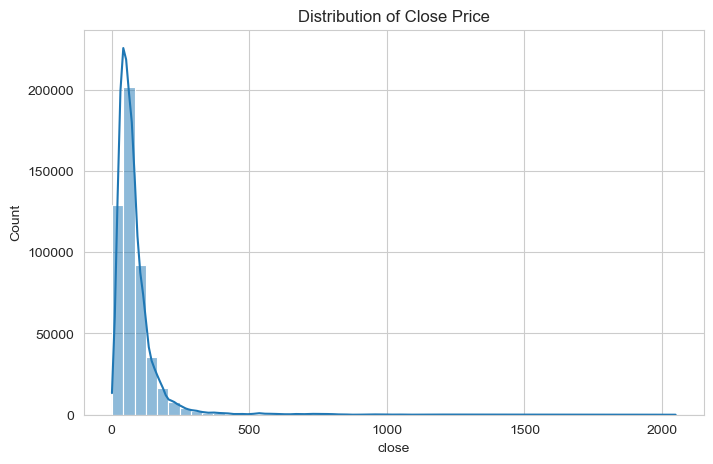

In [87]:
plt.figure(figsize= (8,5))
sns.histplot(stock_price_df["close"], bins = 50, kde=True)
plt.title("Distribution of Close Price")
plt.show()

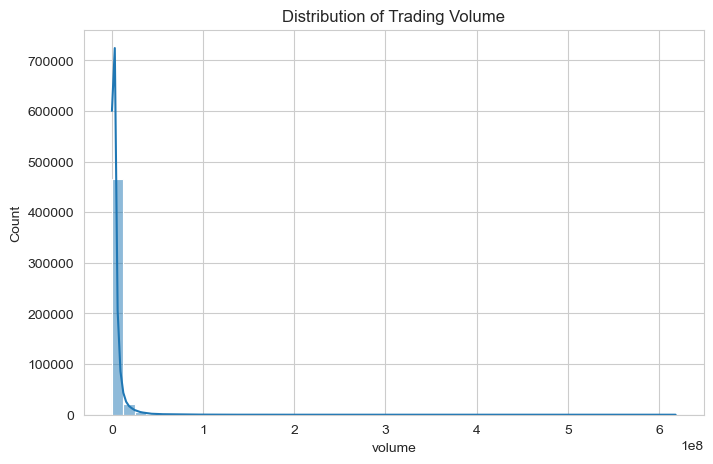

In [88]:
plt.figure(figsize= (8,5))
sns.histplot(stock_price_df["volume"], bins = 50, kde=True)
plt.title("Distribution of Trading Volume")
plt.show()

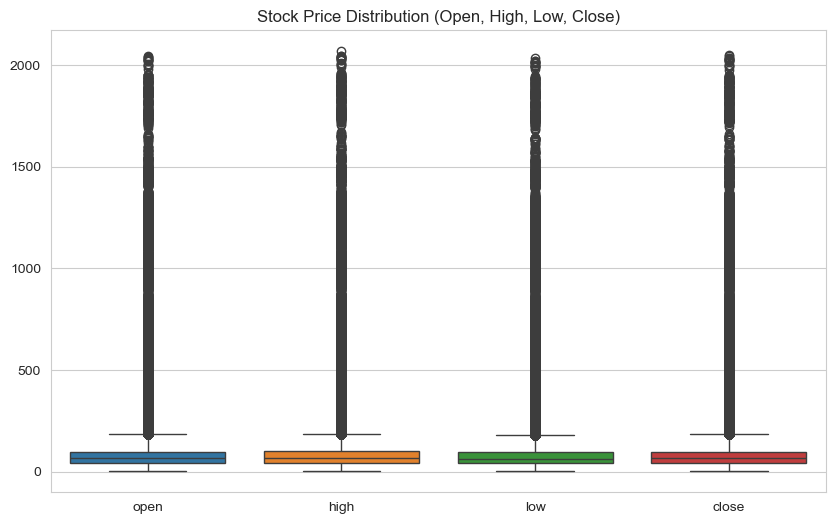

In [96]:
cols = ["open", "high", "low", "close"]
plt.figure(figsize= (10,6))
sns.boxplot(data = stock_price_df[cols])
plt.title("Stock Price Distribution (Open, High, Low, Close)")
plt.show()

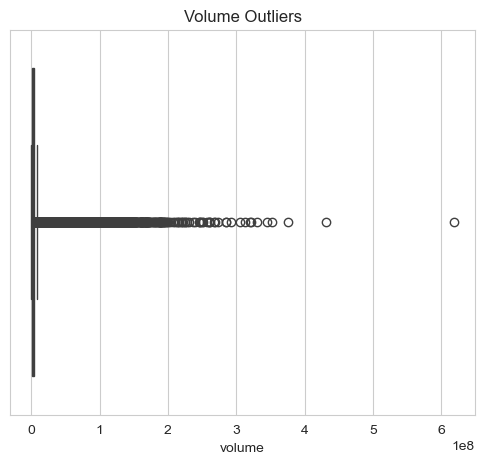

In [98]:
plt.figure(figsize= (6,5))
sns.boxplot(x = stock_price_df["volume"])
plt.title("Volume Outliers")
plt.show()